In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Set a nice default style
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['font.size'] = 12

In [2]:
df = pd.read_excel('absorption_spectra_chlam.xlsx')
wavelength = df['Wavelength']
abs_cpris = df['Chlamydomonas_Cpriscuii']
abs_creind = df['Chlamydomonas_Creindhardtii']

Text(0.5, 0, 'Wavelength (nm)')

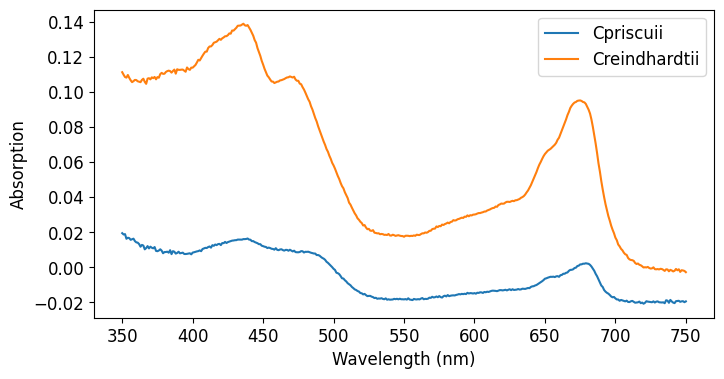

In [3]:
plt.plot(wavelength, abs_cpris, label = 'Cpriscuii')
plt.plot(wavelength, abs_creind, label = 'Creindhardtii')
plt.legend()
plt.ylabel('Absorption')
plt.xlabel('Wavelength (nm)')

Text(0.5, 0, 'Wavelength (nm)')

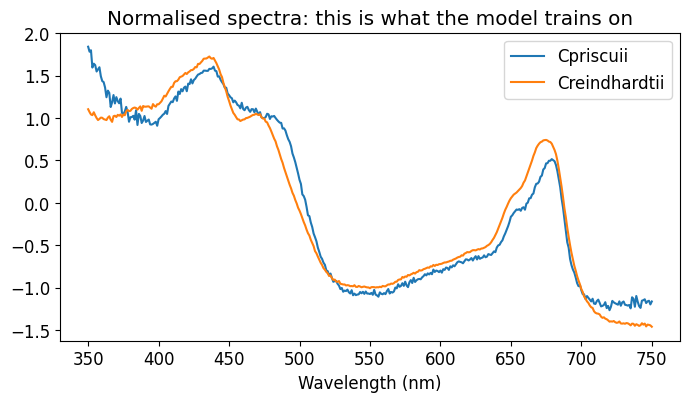

In [4]:
plt.title('Normalised spectra: this is what the model trains on')
plt.plot(wavelength, (np.array(abs_cpris) - np.mean(abs_cpris))/np.std(abs_cpris), label = 'Cpriscuii')
plt.plot(wavelength, (np.array(abs_creind) - np.mean(abs_creind))/np.std(abs_creind), label = 'Creindhardtii')
plt.legend()
plt.xlabel('Wavelength (nm)')

In [5]:
def data_creation(N_training_, N_validation_, noise_level):
    # set seed for reproduction purposes
    
    cpris_training = torch.zeros(N_training_ + N_validation_, len(wavelength))
    creind_training = torch.zeros(N_training_ + N_validation_, len(wavelength))
    for i in range(N_training_ + N_validation_):
        cpris_training[i, :] = torch.tensor(abs_cpris.values, dtype=torch.float32) + noise_level * torch.randn(len(wavelength))
        creind_training[i, :] = torch.tensor(abs_creind.values, dtype=torch.float32) + noise_level * torch.randn(len(wavelength))
        # if i == 0:
        #     plt.plot(wavelength, cpris_training[i, :], label = 'Cpris')
        #     plt.plot(wavelength, creind_training[i, :], label = 'Creind')
        #     plt.legend()
        #     plt.show()

    # combine into dataset with labels
    X = torch.cat([cpris_training, creind_training], dim=0)

    # 0 = cpris, 1 = creind
    y = torch.cat([torch.zeros(N_training_ + N_validation_),torch.ones(N_training_ + N_validation_)], dim=0)

    # shuffle first
    perm = torch.randperm(X.shape[0])
    X, y = X[perm], y[perm]

    # compute stats on training portion only
    mean = X[:2*N_training_].mean(dim=0)
    std  = X[:2*N_training_].std(dim=0) + 1e-8

    # normalize full dataset
    X_norm = (X - mean) / std

    # split up datasets
    X_train_, y_train_ = X_norm[:2*N_training_],  y[:2*N_training_]
    X_val_,   y_val_   = X_norm[2*N_training_:],  y[2*N_training_:]
    return X_train_, y_train_, X_val_, y_val_

In [6]:
def training_loop(nr_epochs, X_train_, y_train_, X_val_, y_val_):
    model = nn.Sequential(
    nn.Linear(len(wavelength), 64),
    nn.ReLU(),
    nn.Linear(64, 1)
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs   = []

    epochs_list = []

    for epoch in range(nr_epochs):
        model.train()
        optimizer.zero_grad()

        pred = model(X_train_).squeeze() # same shape as y_train
        loss = nn.BCEWithLogitsLoss()(pred[:], y_train_)
        loss.backward()
        optimizer.step()

        # find probability of logit (pred)
        prob = torch.sigmoid(pred)
        class_choice = (prob >= 0.5).float()  # 1.0 or 0.0

        model.eval()
        with torch.no_grad():
            pred_val = model(X_val_).squeeze() # same shape as y_val
            loss_val = nn.BCEWithLogitsLoss()(pred_val[:], y_val_)

            prob_val = torch.sigmoid(pred_val)
            class_choice_val = (prob_val >= 0.5).float()  # 1.0 or 0.0
            
        # if true, we return a 1. Else 0.
        train_acc = (class_choice == y_train_).float().mean().item() * 100
        val_acc = (class_choice_val == y_val_).float().mean().item() * 100

        train_losses.append(loss.item())
        val_losses.append(loss_val.item()) 
        train_accs.append(train_acc)
        val_accs.append(val_acc) 
        epochs_list.append(epoch)
    return train_losses, val_losses, train_accs, val_accs, epochs_list


In [7]:
model = nn.Sequential(
    nn.Linear(len(wavelength), 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 1)
)

In [8]:
X_train, y_train, X_val, y_val = data_creation(500, 200, .1)
train_losses, val_losses, train_accs, val_accs, epochs_list = training_loop(100, X_train, y_train, X_val, y_val)

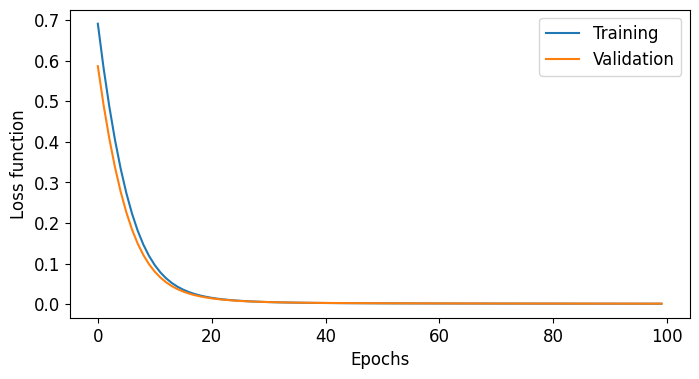

In [9]:
plt.plot(epochs_list, train_losses, label = 'Training')
plt.plot(epochs_list, val_losses, label = 'Validation')
plt.xlabel('Epochs')
plt.ylabel('Loss function')
plt.legend()

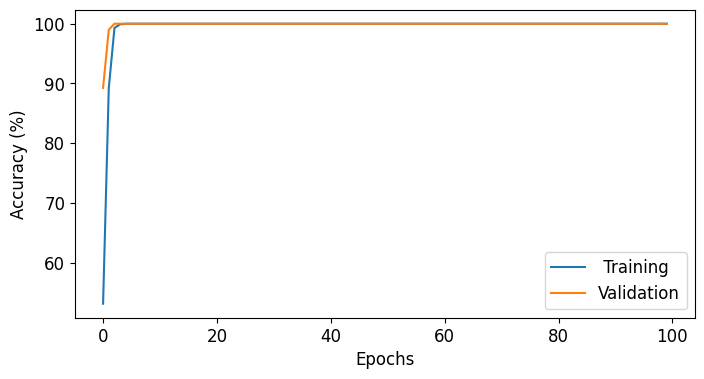

In [10]:
plt.plot(epochs_list, train_accs, label =' Training')
plt.plot(epochs_list, val_accs, label = 'Validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.show()

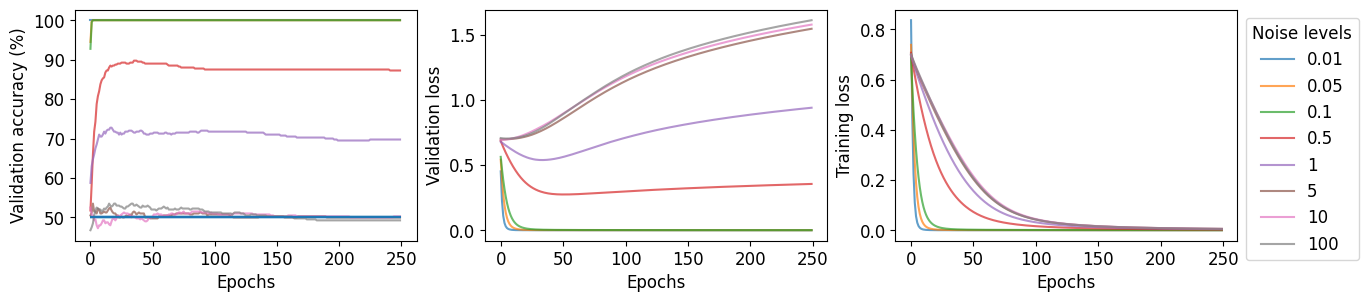

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3))
noise_list = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 100]
# noise_list = [100, 10, 5, 1, 0.5, 0.1, 0.05, 0.01]
for noise in noise_list:
    X_train, y_train, X_val, y_val = data_creation(500, 200, noise)
    train_losses, val_losses, train_accs, val_accs, epochs_list = training_loop(250, X_train, y_train, X_val, y_val)
    axes[0].plot(epochs_list, val_accs, alpha = .7, label = noise)
    axes[0].hlines(50, 0, 250)
    axes[1].plot(epochs_list, val_losses, alpha = .7, label = noise)
    axes[2].plot(epochs_list, train_losses, alpha = .7, label = noise)

axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Validation accuracy (%)')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Validation loss')
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('Training loss')
axes[2].legend(title='Noise levels',bbox_to_anchor = (1,1))